# Fitness Trainer
Authors: Georg and Martina

##### Plan

Change file names (jumping_jacks → jumpingjacks, incorrect name in some cases, etc.), just in case / done in `rename_files.py`

---

**Data loading**

Go through all `.csv` files in the data folder and convert them into dataframes. Add column with activity label (int). Treat phone placement and frequency combinations differently:
- **frequency**: we can then choose only one for the final model
- **placement**: two models in the end - ask user to choose placement before starting

---

*First data processing:* gyro unit and timestamp standardization, NaN handling

---

**Feature extraction**

We will use windows to analyze the data. This way in the final application we can make predictions in real time ("continuously").

For each window:
1. Apply StandardScaler to the raw sensor data of the window *(second data processing)*
2. Extract features from the scaled window:
   - max amplitude
   - median amplitude
   - standard deviation
   - dominant frequency (using FFT)
   - acceleration magnitude (using 3 axes)
   - correlation between axes (orientation)

Create new dataframes with the extracted features and the activity labels / maintain different frequency and placement groups.

The columns should be something like: `['activity_label', 'acc_x_median', 'acc_x_std', 'acc_x_dominant_freq', 'acc_y_median', 'acc_y_std', ...]`

---

**Model selection**

- Plot features per activity label to identify patterns
- Choose the most relevant features OR use all (eval. according to results)
- Try different kernels, parameters, train-test split ratios, etc.
- Evaluate using appropriate metrics
- Choose best model(s)*

---

**Application**

Real-time activity recognition using the best model(s)* & pyglet.

> *Two models: one for `hand`, one for `pocket`


## Imports

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

## Data pre-processing

### Create data frames for the raw data

In [2]:
data_folder = 'data'

# walk through the data folder and collect all CSV file paths
all_csv_paths = []
for dirpath, dirnames, filenames in os.walk(data_folder):
    for filename in filenames:
        if filename.endswith('.csv'):
            all_csv_paths.append((os.path.join(dirpath, filename), filename))

# function to read CSV files and assign activity labels based on filename keywords
# activity labels are numeric because sklearn models require numeric labels
def make_df_list(csv_paths, keyword):
    dfs = []
    for full_path, filename in csv_paths:
        if keyword in filename:
            df = pd.read_csv(full_path)

            if 'running' in filename:
                df['activity_label'] = 0

            elif 'rowing' in filename:
                df['activity_label'] = 1

            elif 'jumpingjacks' in filename:
                df['activity_label'] = 2

            elif 'lifting' in filename:
                df['activity_label'] = 3

            dfs.append(df)
    return dfs

# create separate lists of dataframes for each phone placement and sampling frequency combination
dfs_20Hz_hand = make_df_list(all_csv_paths, '20Hz-hand')
dfs_20Hz_pocket = make_df_list(all_csv_paths, '20Hz-pocket')
dfs_100Hz_hand = make_df_list(all_csv_paths, '100Hz-hand')
dfs_100Hz_pocket = make_df_list(all_csv_paths, '100Hz-pocket')

# create a dictionary to hold all the lists of dataframes for easy access
all_df_lists = {
    '20Hz_hand': dfs_20Hz_hand,
    '20Hz_pocket': dfs_20Hz_pocket,
    '100Hz_hand': dfs_100Hz_hand,
    '100Hz_pocket': dfs_100Hz_pocket
}

In [3]:
# check the number of dataframes in each list to verify that they were read correctly
print("Number of dataframes in dfs_20Hz_hand:", len(dfs_20Hz_hand))
print("Number of dataframes in dfs_20Hz_pocket:", len(dfs_20Hz_pocket))
print("Number of dataframes in dfs_100Hz_hand:", len(dfs_100Hz_hand))
print("Number of dataframes in dfs_100Hz_pocket:", len(dfs_100Hz_pocket))

Number of dataframes in dfs_20Hz_hand: 212
Number of dataframes in dfs_20Hz_pocket: 190
Number of dataframes in dfs_100Hz_hand: 191
Number of dataframes in dfs_100Hz_pocket: 190


### Convert Gyro data to the same unit [deg/s -> rad/s]

In [4]:
# function to check if gyro data is in radians or degrees
def radian_or_degree(df):
    for col in df.columns:
        if 'gyro' in col:
            if df[col].abs().max() > 100:
                return 'degree'
    return 'radian'

# function to convert gyro data from degrees to radians
def degree_to_radian(df):
    for col in df.columns:
        if 'gyro' in col:
            df[col] = np.deg2rad(df[col])
    return df

# convert all gyro data to radians if needed
for dfs in all_df_lists.values():
    for df in dfs:
        if radian_or_degree(df) == 'degree':
            degree_to_radian(df)

### Remove NaN values


In [5]:
# drop any rows with NaN values (if any)
for key, dfs in all_df_lists.items():
    all_df_lists[key] = [df.dropna() for df in dfs]

### Modify timestamps to start at 0s

In [6]:
# create separate lists to hold the timestamp-normalized dataframes
ts_normalized_20Hz_hand = []
ts_normalized_20Hz_pocket = []
ts_normalized_100Hz_hand = []
ts_normalized_100Hz_pocket = []

# create a dictionary to hold the timestamp-normalized dataframes for easy access
all_timestamp_normaized_dfs = {
    '20Hz_hand': ts_normalized_20Hz_hand,
    '20Hz_pocket': ts_normalized_20Hz_pocket,
    '100Hz_hand': ts_normalized_100Hz_hand,
    '100Hz_pocket': ts_normalized_100Hz_pocket
}

# from each row in the timestamp column in each dataframe, the minimum timestamp is subtracted 
for key, dfs in all_df_lists.items():
    for df in dfs:
        min_timestamp = df['timestamp'].min()
        df_tmp = df.copy()
        df_tmp['timestamp'] = (df_tmp['timestamp'] - min_timestamp)
        all_timestamp_normaized_dfs[key].append(df_tmp)

In [7]:
# show the first few rows of one of the timestamp-normalized dataframes to verify that it worked correctly
print(all_timestamp_normaized_dfs['20Hz_hand'][0].head())

   id  timestamp     acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z  \
0   1   0.000000 -6.207352  1.385513 -1.728902 -0.395213  0.096939  2.800580   
1   2   0.062567 -3.385806 -0.283595  1.610046 -3.393400 -4.149738  4.316984   
2   3   0.128285 -2.509397 -1.178308  1.921707  0.048470 -4.837366  5.885586   
3   4   0.187249 -2.469859 -1.844097  0.382194  5.854693 -0.355798  8.094945   
4   5   0.250473 -2.305365 -2.075951  0.216967  5.471198  0.165116  8.841695   

   activity_label  
0               2  
1               2  
2               2  
3               2  
4               2  


## Feature extraction

### Windowing

In [8]:
# window size (in seconds): 2s
# 75% overlap

window_size_seconds = 2

WINDOW_SIZE_20HZ = window_size_seconds * 20
WINDOW_SIZE_100HZ = window_size_seconds * 100
OVERLAP = 0.75

In [9]:
# function to create overlapping windows from a dataframe
def get_windows(df, window_size):
    step = int(window_size * (1 - OVERLAP))
    windows = []
    for start in range(0, len(df) - window_size + 1, step):
        window = df.iloc[start:start + window_size]
        windows.append(window)
    return windows

In [10]:
scaler = StandardScaler()
cols_to_scale = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

def scale_window(window):
    window = window.copy()
    window[cols_to_scale] = scaler.fit_transform(window[cols_to_scale])
    return window


### Feature extraction and creation of data frames with features

In [11]:
cols_to_evaluate = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'acc_magnitude', 'gyro_magnitude']

# function to calculate the dominant frequency of a series using FFT
def get_dominant_frequency(series, sampling_rate):
    n = len(series)
    freqs = np.fft.rfftfreq(n, d=1/sampling_rate)
    fft_magnitude = np.abs(np.fft.rfft(series))
    return freqs[1:][np.argmax(fft_magnitude[1:])]

# function to calculate the correlation between two columns in a window, returning 0 if the correlation is NaN
def get_correlation(window, col1, col2):
    corr = window[col1].corr(window[col2])
    return corr if not np.isnan(corr) else 0.0

# function to extract features from a single scaled window
def extract_features_from_window(window, sampling_rate):
    window = window.copy()
    window['acc_magnitude'] = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
    window['gyro_magnitude'] = np.sqrt(window['gyro_x']**2 + window['gyro_y']**2 + window['gyro_z']**2)

    features = {'activity_label': window['activity_label'].iloc[0]}
    for col in cols_to_evaluate:
        features[f'{col}_max'] = window[col].max()
        features[f'{col}_median'] = window[col].median()
        features[f'{col}_std'] = window[col].std()
        features[f'{col}_dominant_freq'] = get_dominant_frequency(window[col], sampling_rate)
    features['acc_x_y_corr'] = get_correlation(window, 'acc_x', 'acc_y')
    features['acc_x_z_corr'] = get_correlation(window, 'acc_x', 'acc_z')
    features['acc_y_z_corr'] = get_correlation(window, 'acc_y', 'acc_z')
    features['gyro_x_y_corr'] = get_correlation(window, 'gyro_x', 'gyro_y')
    features['gyro_x_z_corr'] = get_correlation(window, 'gyro_x', 'gyro_z')
    features['gyro_y_z_corr'] = get_correlation(window, 'gyro_y', 'gyro_z')
    return features


In [12]:
def build_feature_df(dfs, window_size, sampling_rate):
    all_features = []
    for df in dfs:
        windows = get_windows(df, window_size)
        for window in windows:
            scaled = scale_window(window)
            feats = extract_features_from_window(scaled, sampling_rate)
            all_features.append(feats)
    return pd.DataFrame(all_features)

# split by recording, not by window
splits = {}
for key, dfs in all_timestamp_normaized_dfs.items():
    sampling_rate = 20 if '20Hz' in key else 100
    window_size = WINDOW_SIZE_20HZ if '20Hz' in key else WINDOW_SIZE_100HZ

    train_dfs, test_dfs = train_test_split(dfs, test_size=0.2, random_state=42)

    train_df = build_feature_df(train_dfs, window_size, sampling_rate)
    test_df  = build_feature_df(test_dfs,  window_size, sampling_rate)

    splits[key] = {'train': train_df, 'test': test_df}
    print(f"{key}: {len(train_df)} train windows, {len(test_df)} test windows")


e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= s

20Hz_hand: 2697 train windows, 699 test windows


e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= s

20Hz_pocket: 2495 train windows, 614 test windows


e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= s

100Hz_hand: 2307 train windows, 568 test windows


e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Uni\ITT\assignment-03-activity-recognition-blue-georg-martina\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= s

100Hz_pocket: 2308 train windows, 547 test windows


## Trying out different models

### Kernels and train-test split ratio

In [13]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for key, split in splits.items():
    X_train = split['train'].drop(columns=['activity_label'])
    y_train = split['train']['activity_label']
    X_test  = split['test'].drop(columns=['activity_label'])
    y_test  = split['test']['activity_label']

    print(f"\n{key}:")
    print(f"  {'kernel':<10}  accuracy")
    for kernel in kernels:
        svm = OneVsRestClassifier(SVC(kernel=kernel))
        svm.fit(X_train, y_train)
        acc = accuracy_score(y_test, svm.predict(X_test))
        print(f"  {kernel:<10}  {acc:.3f}")



20Hz_hand:
  kernel      accuracy
  linear      0.845
  rbf         0.878
  poly        0.880
  sigmoid     0.459

20Hz_pocket:
  kernel      accuracy
  linear      0.546
  rbf         0.671
  poly        0.721
  sigmoid     0.448

100Hz_hand:
  kernel      accuracy
  linear      0.813
  rbf         0.820
  poly        0.840
  sigmoid     0.417

100Hz_pocket:
  kernel      accuracy
  linear      0.569
  rbf         0.676
  poly        0.698
  sigmoid     0.276


**Analysis**

[complete]

### Parameters

In [14]:
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__gamma': ['scale', 'auto', 0.01, 0.001],
    'estimator__kernel': ['rbf', 'poly']
}

for key, split in splits.items():
    X_train = split['train'].drop(columns=['activity_label'])
    y_train = split['train']['activity_label']
    X_test  = split['test'].drop(columns=['activity_label'])
    y_test  = split['test']['activity_label']

    grid = GridSearchCV(OneVsRestClassifier(SVC()), param_grid, cv=5, n_jobs=-1)
    grid.fit(X_train, y_train)

    acc = accuracy_score(y_test, grid.predict(X_test))
    print(f"\n{key}:")
    print(f"  best params: {grid.best_params_}")
    print(f"  accuracy: {acc:.3f}")



20Hz_hand:
  best params: {'estimator__C': 100, 'estimator__gamma': 'auto', 'estimator__kernel': 'rbf'}
  accuracy: 0.907

20Hz_pocket:
  best params: {'estimator__C': 10, 'estimator__gamma': 'auto', 'estimator__kernel': 'rbf'}
  accuracy: 0.775

100Hz_hand:
  best params: {'estimator__C': 100, 'estimator__gamma': 'auto', 'estimator__kernel': 'rbf'}
  accuracy: 0.866

100Hz_pocket:
  best params: {'estimator__C': 100, 'estimator__gamma': 'auto', 'estimator__kernel': 'rbf'}
  accuracy: 0.814


**Analysis**

[complete]

### Confusion matrices

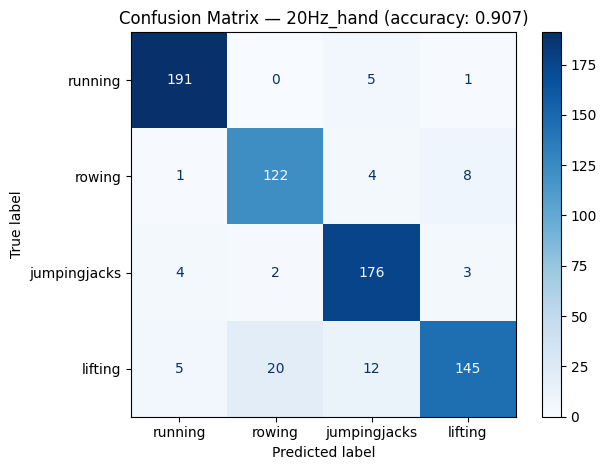

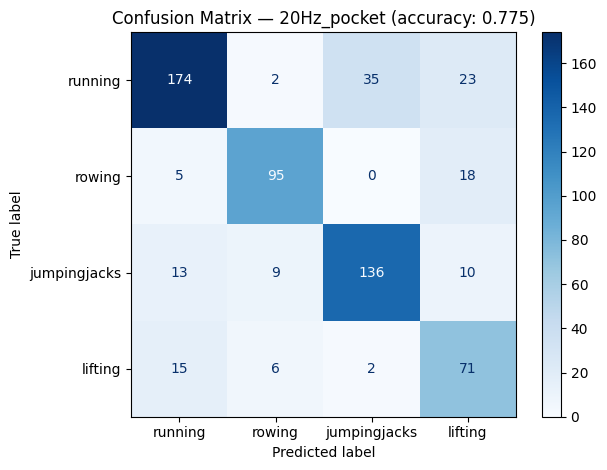

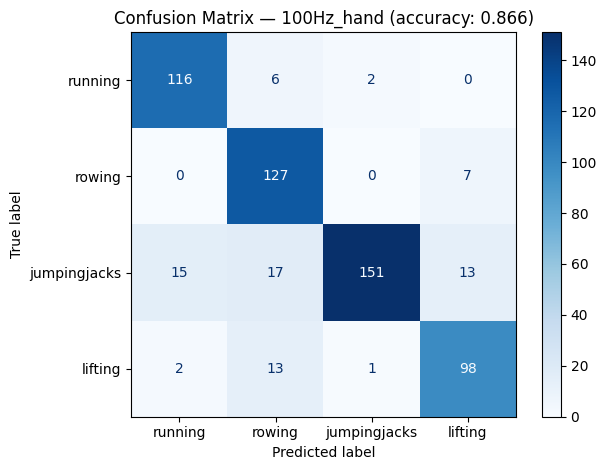

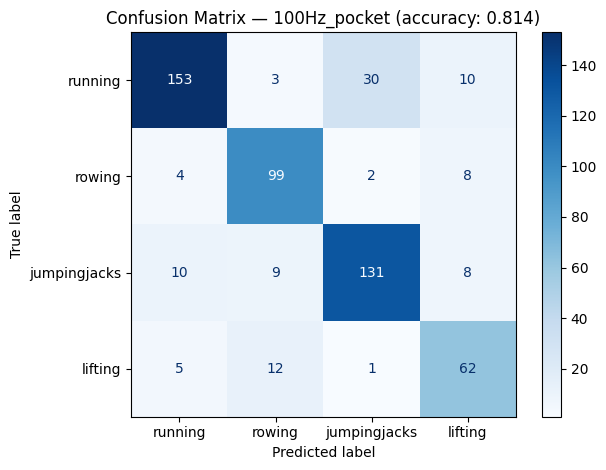

In [15]:
activity_names = ['running', 'rowing', 'jumpingjacks', 'lifting']

# best parameters according to previous grid search results — update after running GridSearch above
best_params = {
    '20Hz_hand':    {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'},
    '20Hz_pocket':  {'C': 10, 'gamma': 'auto',  'kernel': 'rbf'},
    '100Hz_hand':   {'C': 100, 'gamma': 'auto',  'kernel': 'rbf'},
    '100Hz_pocket': {'C': 100, 'gamma': 'auto',  'kernel': 'rbf'}
}

for key, split in splits.items():
    X_train = split['train'].drop(columns=['activity_label'])
    y_train = split['train']['activity_label']
    X_test  = split['test'].drop(columns=['activity_label'])
    y_test  = split['test']['activity_label']

    params = best_params[key]
    svm = OneVsRestClassifier(SVC(kernel=params['kernel'], C=params['C'], gamma=params['gamma']))
    svm.fit(X_train, y_train)

    cm = confusion_matrix(y_test, svm.predict(X_test))
    disp = ConfusionMatrixDisplay(cm, display_labels=activity_names)
    disp.plot(cmap='Blues')
    acc = accuracy_score(y_test, svm.predict(X_test))
    plt.title(f'Confusion Matrix — {key} (accuracy: {acc:.3f})')
    plt.tight_layout()
    plt.show()


**Analysis**

[complete]

## Export model using the best parameters

In [22]:
import joblib
import os

In [16]:
models = {
    '20Hz_hand': None,
    '20Hz_pocket' : None,
    '100Hz_hand': None,
    '100Hz_pocket': None
}

In [28]:
os.makedirs('models', exist_ok=True)
models = {}

# Train final model on ALL data (train + test combined)
for key, split in splits.items():
    full_df = pd.concat([split['train'], split['test']])
    X = full_df.drop(columns=['activity_label'])
    y = full_df['activity_label']

    params = best_params[key]
    model = OneVsRestClassifier(SVC(
        kernel=params['kernel'], C=params['C'],
        gamma=params['gamma'], probability=True
    ))
    model.fit(X, y)
    models[key] = model

In [27]:
for key, model in models.items():
    model_filename = f'models/{key}_svm_model.joblib'
    joblib.dump(model, model_filename)
    print(f'Exported {model_filename}')

Exported models/20Hz_hand_svm_model.joblib
Exported models/20Hz_pocket_svm_model.joblib
Exported models/100Hz_hand_svm_model.joblib
Exported models/100Hz_pocket_svm_model.joblib


### Test imported models

In [25]:
imported_models = {}
for key in models.keys():
    model_filename = f'models/{key}_svm_model.joblib'
    imported_models[key] = joblib.load(model_filename)

In [29]:
# verify accuracy on the held-out test sets
for key, split in splits.items():
    X_test = split['test'].drop(columns=['activity_label'])
    y_test = split['test']['activity_label']

    model = imported_models[key]
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f'{key} - Imported Model Accuracy: {acc:.3f}')

20Hz_hand - Imported Model Accuracy: 0.987
20Hz_pocket - Imported Model Accuracy: 0.985
100Hz_hand - Imported Model Accuracy: 0.998
100Hz_pocket - Imported Model Accuracy: 1.000
